# Optimización y evaluación de los modelos finales

En este notebook se ajustan los hiperparámetros de Regresión Logística y Random Forest mediante `GridSearchCV`. La búsqueda utiliza únicamente el conjunto de entrenamiento y validación cruzada estratificada de cinco particiones. Después, se evalúan con el conjunto de prueba.

También se representan las curvas ROC y las curvas de aprendizaje de ambos modelos.

## Importaciones

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    multilabel_confusion_matrix,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize

## Lectura de los conjuntos de datos

In [2]:
def localizar_raiz_proyecto():
    carpeta_actual = Path.cwd().resolve()

    if (carpeta_actual / "datos").exists():
        return carpeta_actual
    if (carpeta_actual.parent / "datos").exists():
        return carpeta_actual.parent

    raise FileNotFoundError(
        "No se encuentra la carpeta 'datos'. Abre el notebook desde el repositorio."
    )


RAIZ_PROYECTO = localizar_raiz_proyecto()
RUTA_TRAIN = RAIZ_PROYECTO / "datos" / "procesados" / "train.csv"
RUTA_TEST = RAIZ_PROYECTO / "datos" / "procesados" / "test.csv"

df_train = pd.read_csv(RUTA_TRAIN)
df_test = pd.read_csv(RUTA_TEST)

X_train = df_train.drop(columns=["clase"])
y_train = df_train["clase"]
X_test = df_test.drop(columns=["clase"])
y_test = df_test["clase"]

clases = ["otro", "hipotiroidismo", "hipertiroidismo"]

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (7337, 26)
Prueba: (1835, 26)


`X_train` e `y_train` se emplean para buscar los hiperparámetros y realizar la validación cruzada. `X_test` e `y_test` se reservan para la evaluación final.

## Preprocesamiento y validación

In [3]:
variables_numericas = ["edad", "TSH", "T3", "TT4", "T4U", "FTI"]

variables_binarias = [
    "sexo", "tratamiento_con_tiroxina", "consulta_sobre_tiroxina",
    "medicacion_antitiroidea", "enfermo", "embarazada",
    "cirugia_tiroidea", "tratamiento_I131", "consulta_hipotiroidismo",
    "consulta_hipertiroidismo", "litio", "bocio", "tumor",
    "hipopituitarismo", "trastorno_psiquiatrico", "TSH_medida",
    "T3_medida", "TT4_medida", "T4U_medida", "FTI_medido"
]

procesador_numerico = Pipeline([
    ("imputacion", SimpleImputer(strategy="median")),
    ("normalizacion", StandardScaler())
])

procesador_binario = Pipeline([
    ("imputacion", SimpleImputer(strategy="most_frequent"))
])

preprocesador = ColumnTransformer([
    ("numericas", procesador_numerico, variables_numericas),
    ("binarias", procesador_binario, variables_binarias)
])

validacion = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Función de evaluación

In [4]:
def evaluar_modelo(nombre, modelo):
    predicciones = modelo.predict(X_test)

    matrices = multilabel_confusion_matrix(
        y_test, predicciones, labels=clases
    )
    especificidades = []
    for matriz in matrices:
        vn, fp, fn, vp = matriz.ravel()
        especificidades.append(vn / (vn + fp))

    resultados = {
        "Modelo": nombre,
        "Exactitud": accuracy_score(y_test, predicciones),
        "Sensibilidad macro": recall_score(
            y_test, predicciones, average="macro", zero_division=0
        ),
        "Especificidad macro": np.mean(especificidades),
        "Precisión macro": precision_score(
            y_test, predicciones, average="macro", zero_division=0
        ),
        "F1 macro": f1_score(
            y_test, predicciones, average="macro", zero_division=0
        ),
    }

    print(nombre)
    for metrica, valor in list(resultados.items())[1:]:
        print(f"{metrica}: {valor:.4f}")

    metricas_clase = pd.DataFrame({
        "Sensibilidad": recall_score(
            y_test, predicciones, labels=clases,
            average=None, zero_division=0
        ),
        "Especificidad": especificidades,
        "Precisión": precision_score(
            y_test, predicciones, labels=clases,
            average=None, zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, predicciones, labels=clases,
            average=None, zero_division=0
        ),
    }, index=clases)
    display(metricas_clase.round(4))

    matriz = confusion_matrix(y_test, predicciones, labels=clases)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        matriz, annot=True, fmt="d", cmap="Blues",
        xticklabels=clases, yticklabels=clases
    )
    plt.title(f"Matriz de confusión - {nombre}")
    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")
    plt.tight_layout()
    plt.show()

    return resultados

## LR

In [5]:
pipeline_lr = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LogisticRegression(
        solver="saga",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

parametros_lr = {
    "modelo__C": [0.01, 0.1, 1, 10, 100],
    "modelo__penalty": ["l1", "l2"]
}

busqueda_lr = GridSearchCV(
    pipeline_lr,
    parametros_lr,
    scoring="f1_macro",
    cv=validacion,
    n_jobs=-1,
    verbose=1
)

busqueda_lr.fit(X_train, y_train)

print("Mejores hiperparámetros:", busqueda_lr.best_params_)
print("F1 macro medio:", round(busqueda_lr.best_score_, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores hiperparámetros: {'modelo__C': 10, 'modelo__penalty': 'l2'}
F1 macro medio: 0.7621


Regresión Logística ajustada
Exactitud: 0.9232
Sensibilidad macro: 0.9318
Especificidad macro: 0.9581
Precisión macro: 0.6849
F1 macro: 0.7571


,Sensibilidad,Especificidad,Precisión,F1-Score
otro,0.9203,0.9494,0.9941,0.9558
hipotiroidismo,0.9621,0.9724,0.7299,0.8301
hipertiroidismo,0.9130,0.9525,0.3307,0.4855


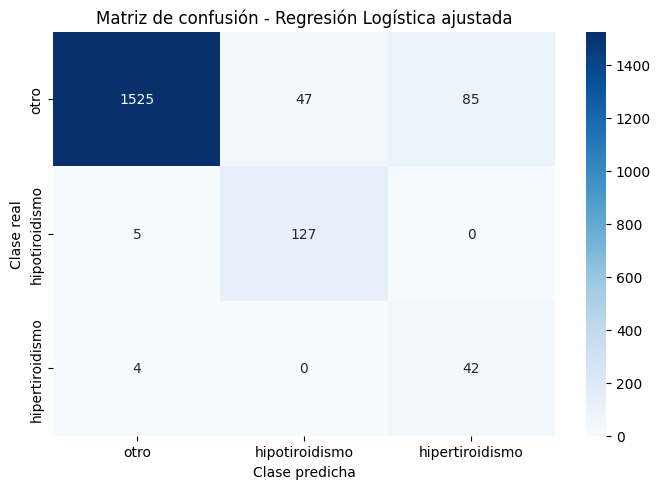

In [6]:
mejor_lr = busqueda_lr.best_estimator_
resultados_lr = evaluar_modelo("Regresión Logística ajustada", mejor_lr)

## RF

In [7]:
pipeline_rf = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

parametros_rf = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [None, 10, 20],
    "modelo__min_samples_split": [2, 5]
}

busqueda_rf = GridSearchCV(
    pipeline_rf,
    parametros_rf,
    scoring="f1_macro",
    cv=validacion,
    n_jobs=-1,
    verbose=1
)

busqueda_rf.fit(X_train, y_train)

print("Mejores hiperparámetros:", busqueda_rf.best_params_)
print("F1 macro medio:", round(busqueda_rf.best_score_, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores hiperparámetros: {'modelo__max_depth': None, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 200}
F1 macro medio: 0.9195


Random Forest ajustado
Exactitud: 0.9787
Sensibilidad macro: 0.8607
Especificidad macro: 0.9589
Precisión macro: 0.8867
F1 macro: 0.8714


,Sensibilidad,Especificidad,Precisión,F1-Score
otro,0.9885,0.8876,0.9879,0.9882
hipotiroidismo,0.9848,0.9947,0.9353,0.9594
hipertiroidismo,0.6087,0.9944,0.7368,0.6667


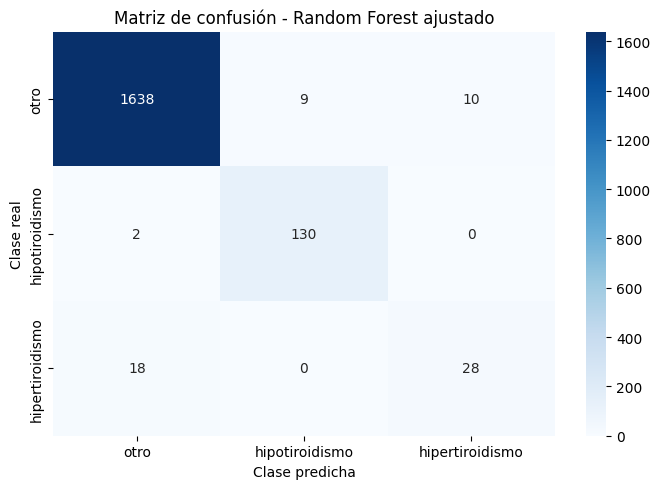

In [8]:
mejor_rf = busqueda_rf.best_estimator_
resultados_rf = evaluar_modelo("Random Forest ajustado", mejor_rf)

## Comparación final

In [9]:
tabla_resultados = pd.DataFrame([resultados_lr, resultados_rf])
tabla_resultados.set_index("Modelo").round(4)

,Exactitud,Sensibilidad macro,Especificidad macro,Precisión macro,F1 macro
Modelo,,,,,
Regresión Logística ajustada,0.9232,0.9318,0.9581,0.6849,0.7571
Random Forest ajustado,0.9787,0.8607,0.9589,0.8867,0.8714


## Curvas ROC

Para cada clase se aplica el enfoque uno contra el resto: la clase analizada se considera positiva y las otras dos se agrupan como negativas. El área bajo la curva se muestra mediante el valor AUC.

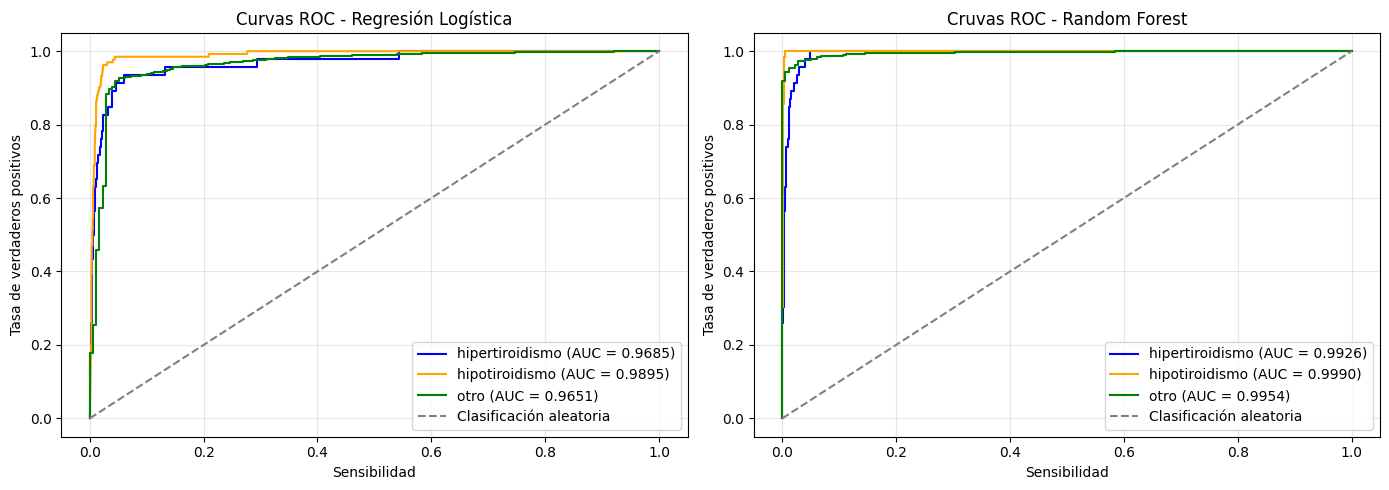

In [16]:
def dibujar_roc(ax, nombre, modelo):
    probabilidades = modelo.predict_proba(X_test)
    clases_modelo = list(modelo.named_steps["modelo"].classes_)

    orden_roc = [
        "hipertiroidismo",
        "hipotiroidismo",
        "otro"
    ]

    colores = {
        "hipertiroidismo": "blue",
        "hipotiroidismo": "orange",
        "otro": "green"
    }

    y_test_binario = label_binarize(
        y_test,
        classes=orden_roc
    )

    auc_clases = {}

    for i, clase in enumerate(orden_roc):
        posicion = clases_modelo.index(clase)
        probabilidades_clase = probabilidades[:, posicion]

        fpr, tpr, _ = roc_curve(
            y_test_binario[:, i],
            probabilidades_clase
        )

        valor_auc = auc(fpr, tpr)
        auc_clases[clase] = valor_auc

        ax.plot(
            fpr,
            tpr,
            color=colores[clase],
            label=f"{clase} (AUC = {valor_auc:.4f})"
        )

    ax.plot(
        [0, 1],
        [0, 1],
        color="gray",
        linestyle="--",
        label="Clasificación aleatoria"
    )

    ax.set_title(nombre)
    ax.set_xlabel("Sensibilidad")
    ax.set_ylabel("Tasa de verdaderos positivos")
    ax.legend()
    ax.grid(alpha=0.3)

    return auc_clases


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

auc_lr = dibujar_roc(
    axes[0],
    "Curvas ROC - Regresión Logística",
    mejor_lr
)

auc_rf = dibujar_roc(
    axes[1],
    "Cruvas ROC - Random Forest",
    mejor_rf
)

plt.tight_layout()
plt.show()

In [11]:
tabla_auc = pd.DataFrame(
    [auc_lr, auc_rf],
    index=["Regresión Logística", "Random Forest"]
)
tabla_auc.round(4)

,otro,hipotiroidismo,hipertiroidismo
Regresión Logística,0.9651,0.9895,0.9685
Random Forest,0.9954,0.9990,0.9926


## Curvas de aprendizaje

Las curvas de aprendizaje se calculan solamente con el conjunto de entrenamiento. Comparan el F1-Score macro de entrenamiento y validación a medida que aumenta el número de registros utilizados.

Calculando las curvas de aprendizaje...


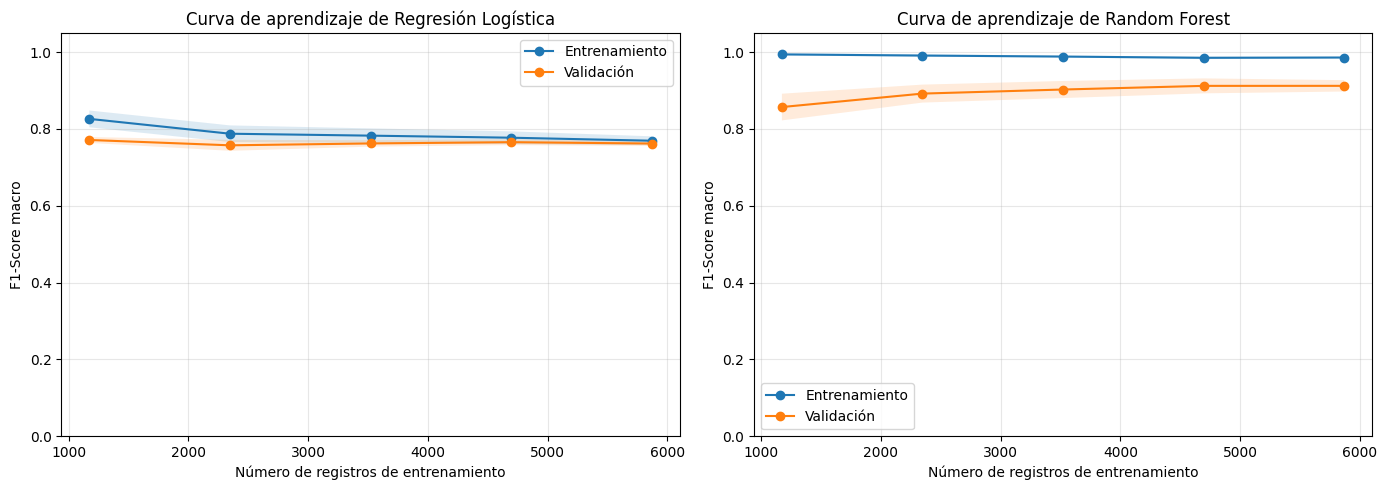

In [19]:
def dibujar_curva_aprendizaje(ax, nombre, modelo):
    tamanos, puntuacion_train, puntuacion_val = learning_curve(
        modelo,
        X_train,
        y_train,
        train_sizes=np.linspace(0.2, 1.0, 5),
        cv=validacion,
        scoring="f1_macro",
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    media_train = puntuacion_train.mean(axis=1)
    desviacion_train = puntuacion_train.std(axis=1)
    media_val = puntuacion_val.mean(axis=1)
    desviacion_val = puntuacion_val.std(axis=1)

    ax.plot(tamanos, media_train, marker="o", label="Entrenamiento")
    ax.plot(tamanos, media_val, marker="o", label="Validación")
    ax.fill_between(
        tamanos, media_train - desviacion_train,
        media_train + desviacion_train, alpha=0.15
    )
    ax.fill_between(
        tamanos, media_val - desviacion_val,
        media_val + desviacion_val, alpha=0.15
    )
    ax.set_title(nombre)
    ax.set_xlabel("Número de registros de entrenamiento")
    ax.set_ylabel("F1-Score macro")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend()


print("Calculando las curvas de aprendizaje...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dibujar_curva_aprendizaje(axes[0], "Curva de aprendizaje de Regresión Logística", mejor_lr)
dibujar_curva_aprendizaje(axes[1], "Curva de aprendizaje de Random Forest", mejor_rf)

plt.tight_layout()
plt.show()

## Guardado de los modelos finales

In [20]:
ruta_modelos = RAIZ_PROYECTO / "modelos"
ruta_modelos.mkdir(parents=True, exist_ok=True)

artefacto_lr = {
    "modelo": mejor_lr,
    "columnas": X_train.columns.tolist()
}
artefacto_rf = {
    "modelo": mejor_rf,
    "columnas": X_train.columns.tolist()
}

joblib.dump(artefacto_lr, ruta_modelos / "modelo_lr_tiroides.joblib")
joblib.dump(artefacto_rf, ruta_modelos / "modelo_rf_tiroides.joblib")

print("Modelos guardados en:", ruta_modelos)

Modelos guardados en: C:\Users\frana\Desktop\codigo\prediccion-enfermedades-tiroideas\modelos


## Conclusión

La selección de hiperparámetros se basa en el F1-Score macro medio de la validación cruzada. La comparación definitiva se realiza con el conjunto de prueba, que se mantiene separado durante todo el ajuste. Las curvas ROC permiten estudiar la capacidad de discriminación por clase y las curvas de aprendizaje muestran la evolución del rendimiento al aumentar los datos de entrenamiento.